# Zomato Restaurant Data — Exploratory Data Analysis

**Author:** Bhavesh Meena

This notebook explores the Zomato restaurants dataset (~9,500 restaurants across 15 countries) to
understand **where** restaurants are concentrated, **what** they cost and serve, and **which factors
relate to higher customer ratings**.

### Questions we answer
1. How are restaurants distributed across countries and cities?
2. How are ratings distributed, and what counts as "good"?
3. Which cuisines are most common, and which earn the best ratings?
4. Do online delivery / table booking relate to ratings and engagement (votes)?
5. Within one market (India), how does cost relate to rating?
6. Which numeric features move together?

### Dataset
`zomato.csv` (one row per restaurant) joined with `Country-Code.xlsx` (country-code → country name).
Key columns: *Cuisines, Average Cost for two, Currency, Has Table booking, Has Online delivery,
Price range, Aggregate rating, Rating text, Votes, City, Country Code.*


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_columns", 50)

## 1. Load and join the data

In [2]:
df = pd.read_csv("zomato.csv", encoding="latin-1")
country = pd.read_excel("Country-Code.xlsx")

df = df.merge(country, on="Country Code", how="left")
print("Restaurants:", df.shape[0], "| Columns:", df.shape[1])
df.head()

Restaurants: 9551 | Columns: 22


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


## 2. Dataset overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [4]:
# Missing values and duplicates
missing = df.isna().sum()
print("Columns with missing values:")
print(missing[missing > 0], "\n")
print("Duplicate Restaurant IDs:", df["Restaurant ID"].duplicated().sum())

Columns with missing values:
Cuisines    9
dtype: int64 

Duplicate Restaurant IDs: 0


## 3. Data cleaning

Two cleaning steps matter for honest analysis:

- A small number of **Cuisines** values are missing — we label them `Unknown`.
- An **Aggregate rating of 0** is not a real score; the matching `Rating text` is *"Not rated"*.
  We keep a clean `rating` column (0 → `NaN`) so unrated restaurants don't drag the averages down.


In [5]:
df = df.drop_duplicates(subset="Restaurant ID")
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

df["rating"] = df["Aggregate rating"].replace(0, np.nan)
print("Unrated restaurants (rating = 0):", df["Aggregate rating"].eq(0).sum())
print("Rated restaurants:", df["rating"].notna().sum())
df["Rating text"].value_counts()

Unrated restaurants (rating = 0): 2148
Rated restaurants: 7403


Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64

## 4. Geographic distribution\n\nWhere are these restaurants located?

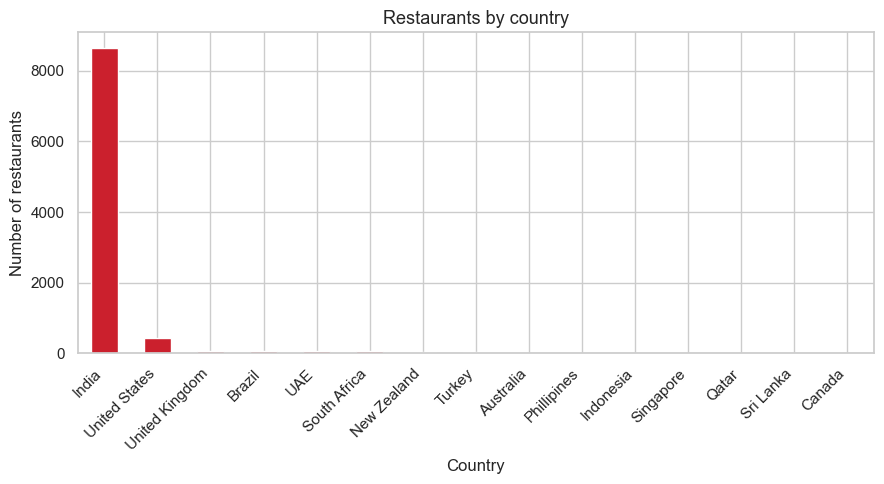

Country
India             90.6 %
United States      4.5 %
United Kingdom     0.8 %
Name: count, dtype: object


In [6]:
by_country = df["Country"].value_counts()
ax = by_country.plot(kind="bar", color="#cb202d")
ax.set_title("Restaurants by country")
ax.set_ylabel("Number of restaurants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

print((by_country / by_country.sum() * 100).round(1).head(3).astype(str) + " %")

> The dataset is **dominated by India** — so any cross-country comparison of cost or rating is heavily India-weighted. We keep this in mind below.

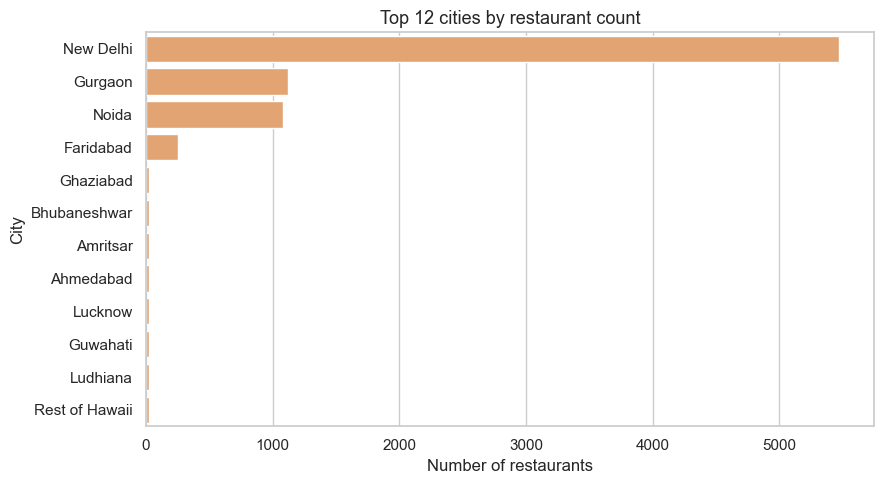

In [7]:
top_cities = df["City"].value_counts().head(12)
ax = sns.barplot(x=top_cities.values, y=top_cities.index, color="#f4a261")
ax.set_title("Top 12 cities by restaurant count")
ax.set_xlabel("Number of restaurants")
plt.tight_layout(); plt.show()

## 5. Ratings analysis

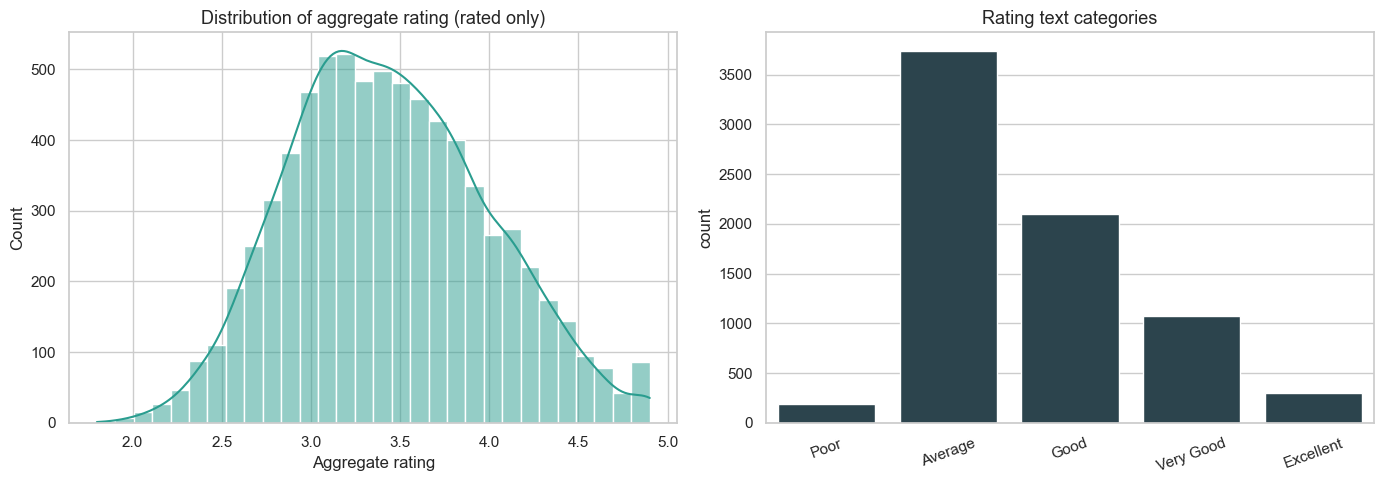

Median rating: 3.4


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["rating"].dropna(), bins=30, kde=True, color="#2a9d8f", ax=axes[0])
axes[0].set_title("Distribution of aggregate rating (rated only)")
axes[0].set_xlabel("Aggregate rating")

order = ["Poor", "Average", "Good", "Very Good", "Excellent"]
present = [o for o in order if o in df["Rating text"].unique()]
sns.countplot(data=df[df["Rating text"].isin(present)], x="Rating text",
              order=present, color="#264653", ax=axes[1])
axes[1].set_title("Rating text categories")
axes[1].set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

print("Median rating:", df["rating"].median())

## 6. Cuisines\n\nCuisines are comma-separated, so we explode them to count individual cuisines.

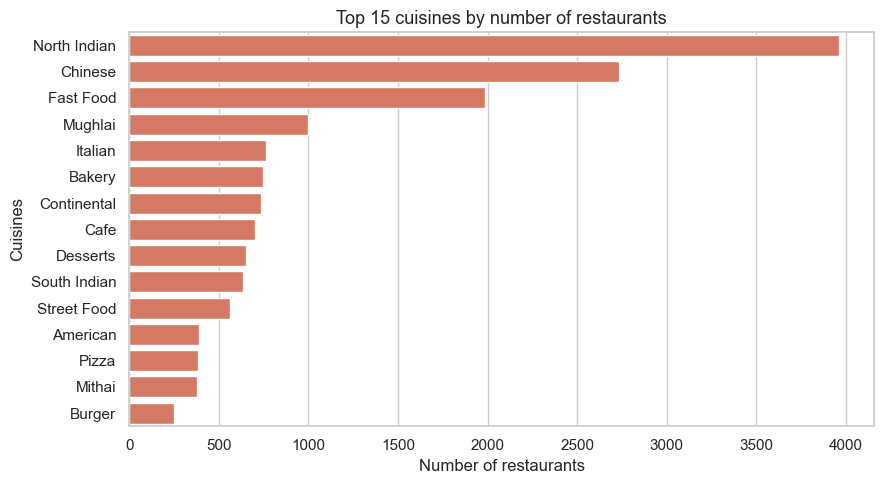

In [9]:
cuisine_series = (df["Cuisines"].str.split(", ")
                  .explode().str.strip())
top_cuisines = cuisine_series.value_counts().head(15)
ax = sns.barplot(x=top_cuisines.values, y=top_cuisines.index, color="#e76f51")
ax.set_title("Top 15 cuisines by number of restaurants")
ax.set_xlabel("Number of restaurants")
plt.tight_layout(); plt.show()

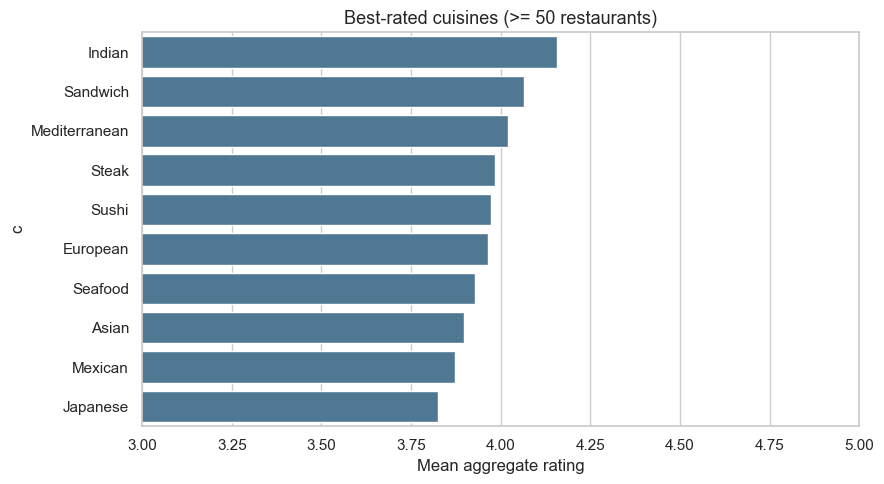

,mean,count
c,,
Indian,4.16,66
Sandwich,4.07,53
Mediterranean,4.02,110
Steak,3.99,62
Sushi,3.97,75
European,3.96,146
Seafood,3.93,171
Asian,3.90,228
Mexican,3.87,174


In [10]:
# Which cuisines are best rated? (only cuisines with >= 50 restaurants, to avoid noise)
exploded = df.assign(c=df["Cuisines"].str.split(", ")).explode("c")
exploded["c"] = exploded["c"].str.strip()
g = exploded.groupby("c")["rating"].agg(["mean", "count"])
best = g[g["count"] >= 50].sort_values("mean", ascending=False).head(10)
ax = sns.barplot(x=best["mean"], y=best.index, color="#457b9d")
ax.set_title("Best-rated cuisines (>= 50 restaurants)")
ax.set_xlabel("Mean aggregate rating"); ax.set_xlim(3.0, 5.0)
plt.tight_layout(); plt.show()
best.round(2)

## 7. Online delivery & table booking\n\nDo these service features relate to ratings and engagement?

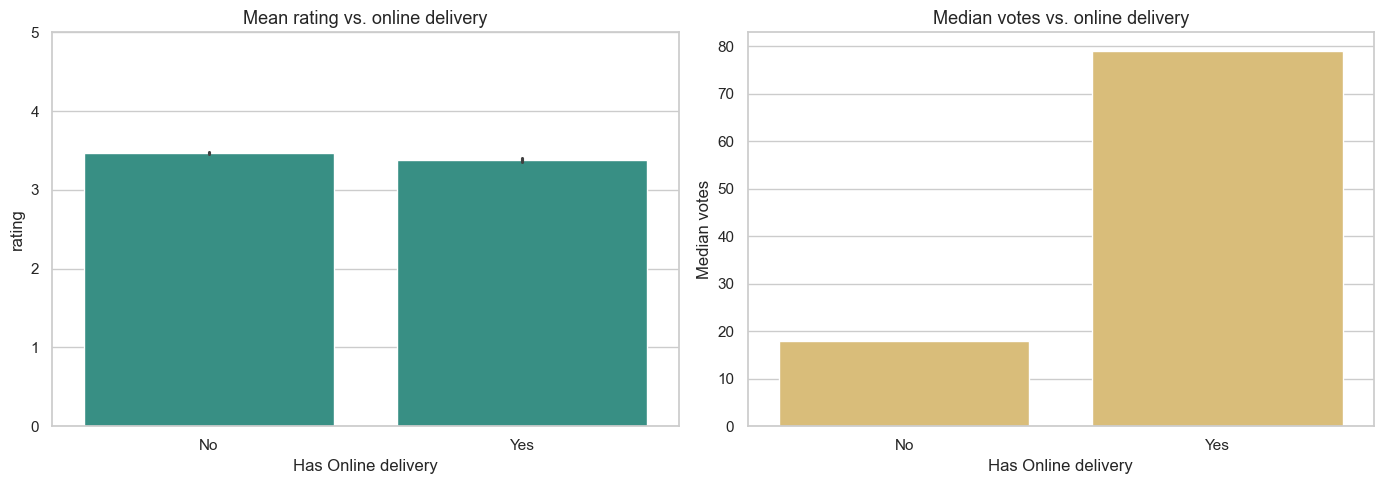

                     rating  Votes
Has Online delivery               
No                     3.47   18.0
Yes                    3.38   79.0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x="Has Online delivery", y="rating",
            estimator=np.mean, color="#2a9d8f", ax=axes[0])
axes[0].set_title("Mean rating vs. online delivery")
axes[0].set_ylim(0, 5)

# Engagement: votes tend to be skewed, so use median
votes = df.groupby("Has Online delivery")["Votes"].median()
sns.barplot(x=votes.index, y=votes.values, color="#e9c46a", ax=axes[1])
axes[1].set_title("Median votes vs. online delivery")
axes[1].set_ylabel("Median votes")
plt.tight_layout(); plt.show()

print(df.groupby("Has Online delivery")[["rating", "Votes"]].agg({"rating": "mean", "Votes": "median"}).round(2))

> Restaurants offering **online delivery** tend to collect **far more votes** (more customer engagement), even where the average rating difference is modest.

## 8. Cost vs. rating (India only)

`Average Cost for two` is recorded in each country's local currency, so it is **not comparable across
countries**. We isolate **India** (the largest, single-currency market) to study the cost ↔ rating
relationship cleanly.


India restaurants with a cost value: 8643


/var/folders/sm/jj42vtnd2xdc0z_kw1l130zw0000gn/T/ipykernel_58268/202072972.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=india, x="Price range", y="rating", palette="YlOrRd", ax=axes[1])


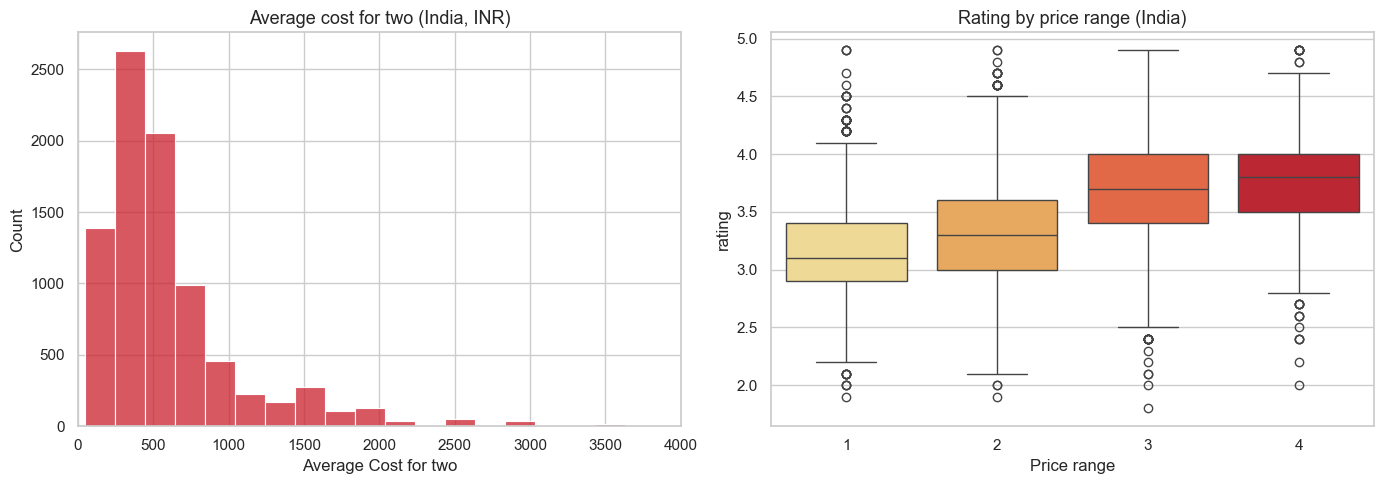

Price range
1    3.19
2    3.31
3    3.68
4    3.73
Name: rating, dtype: float64


In [12]:
india = df[(df["Country"] == "India") & (df["Average Cost for two"] > 0)].copy()
print("India restaurants with a cost value:", len(india))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(india["Average Cost for two"], bins=40, color="#cb202d", ax=axes[0])
axes[0].set_title("Average cost for two (India, INR)")
axes[0].set_xlim(0, 4000)

sns.boxplot(data=india, x="Price range", y="rating", palette="YlOrRd", ax=axes[1])
axes[1].set_title("Rating by price range (India)")
plt.tight_layout(); plt.show()

print(india.groupby("Price range")["rating"].mean().round(2))

> Higher **price ranges** are associated with **higher average ratings** in India — pricier restaurants tend to be rated better (and reviewed more).

## 9. Correlation between numeric features

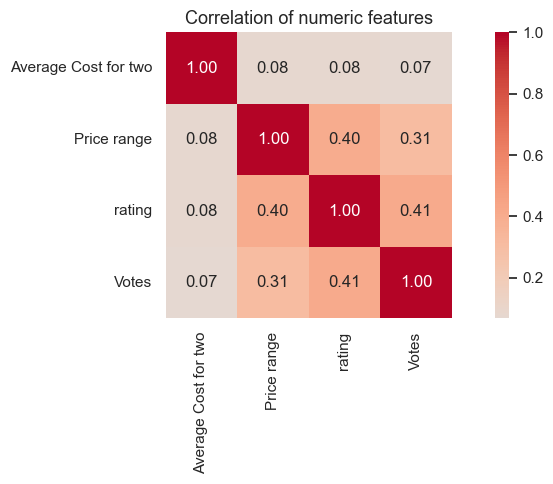

,Average Cost for two,Price range,rating,Votes
Average Cost for two,1.00,0.08,0.08,0.07
Price range,0.08,1.00,0.40,0.31
rating,0.08,0.40,1.00,0.41
Votes,0.07,0.31,0.41,1.00


In [13]:
num = df[["Average Cost for two", "Price range", "rating", "Votes"]].copy()
corr = num.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True)
plt.title("Correlation of numeric features")
plt.tight_layout(); plt.show()
corr.round(2)

## 10. Key insights

1. **Geography is lopsided.** India accounts for the large majority of restaurants, so global
   averages are effectively India averages — cross-country comparisons must be read with care.
2. **Ratings cluster in the 3.0–4.0 band**, with relatively few truly "Excellent" venues; a 0 rating
   simply means *not yet rated* and was excluded from rating statistics.
3. **North Indian, Chinese and Fast Food** are the most common cuisines, while some niche cuisines
   (with enough sample) post the highest average ratings.
4. **Online delivery is linked to much higher engagement** (votes), making it a strong signal of an
   active, visible restaurant rather than just a slightly higher score.
5. **Price tracks rating in India** — higher price ranges show higher mean ratings and more votes.
6. **Votes correlate with rating** more than raw cost does, suggesting popularity/visibility is a
   better predictor of a strong rating than price alone.

### Caveats
- `Average Cost for two` is in local currency and is only compared *within* India here.
- The data is a snapshot; ratings and delivery availability change over time.
